In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

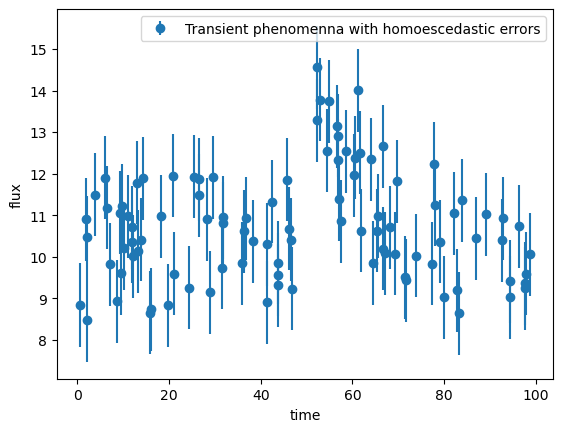

In [8]:
#full parameter bayesian estimate
data= np.load('transient.npy')

plt.errorbar(data[:,0], data[:,1], data[:,2], fmt='o', label='Transient phenomenna with homoescedastic errors')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend();

In [10]:
def burst(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0))) #possible model

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


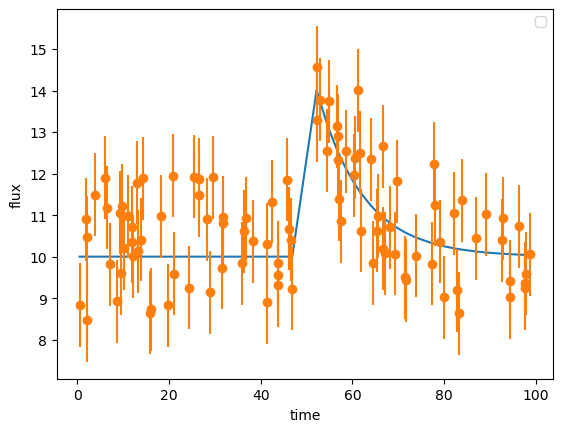

In [11]:
#lets see with random parameters
theta_quick = 5,10,50,0.1
t=data[:,0]
model=burst(theta_quick,t)
plt.plot(t,model)
plt.errorbar(data[:,0], data[:,1], data[:,2], fmt='o')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend();

#seems to be good

In [12]:
#lets see the likehood 

t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)

def loglikehood(theta,data,model=burst):
    x,y,sigma= data[:,0],data[:,1],data[:,2]
    y_fit = model(theta, x)
    return -0.5 * np.sum((y-y_fit)**2/(sigma**2))

def logprior(theta):
    A,b,t0,alpha=theta 
    if Amin < A < Amax and bmin < b < bmax and t0min < t0 < t0max and alphamin < alpha < alphamax:
        return - np.log(alpha) #the otehrs prios are constant.
    return -np.inf #0 prob
                   
def LogPosterior(theta,data,model=burst):
    return loglikehood(theta, data, model) + logprior(theta)
    

In [13]:
import emcee
import scipy.stats

ndim = 4  # number of parameters in the model
nwalkers = 8  # number of MCMC walkers
burn = 1000  # "burn-in" period to let chains stabilize
nsteps = 10000  # number of MCMC steps to take **for each walker**

# initialize theta 
starting_guesses = theta_quick + np.random.random((nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior, args=[data, burst])
sampler.run_mcmc(starting_guesses, nsteps)
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)
emcee_acep = sampler.acceptance_fraction  


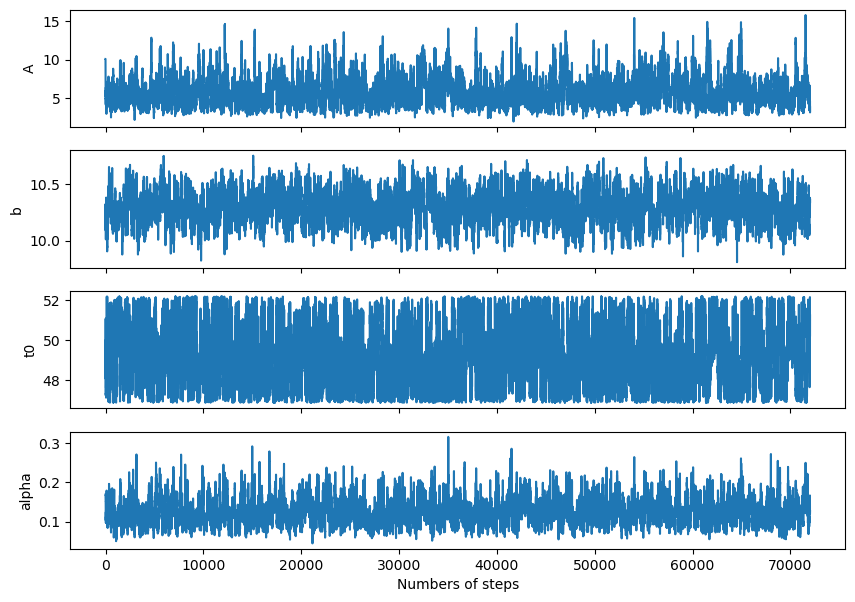

In [14]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
labels = ["A","b","t0","alpha"]
N=np.arange(len(emcee_trace[:,1]))
for i in range(ndim):
    ax=axes[i]
    ax.plot(N,emcee_trace[:,i])
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("Numbers of steps");

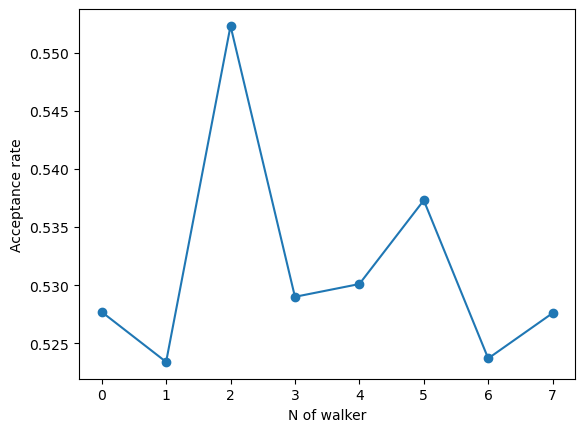

In [15]:
plt.plot(range(nwalkers), emcee_acep, marker='o')
plt.xlabel('N of walker')
plt.ylabel('Acceptance rate');

In [16]:
tau = sampler.get_autocorr_time()
print(tau)
thin = int(max(tau))

[87.81532106 84.79121985 80.10502877 80.3679693 ]


In [17]:
emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True)
print(emcee_trace.shape)

(824, 4)


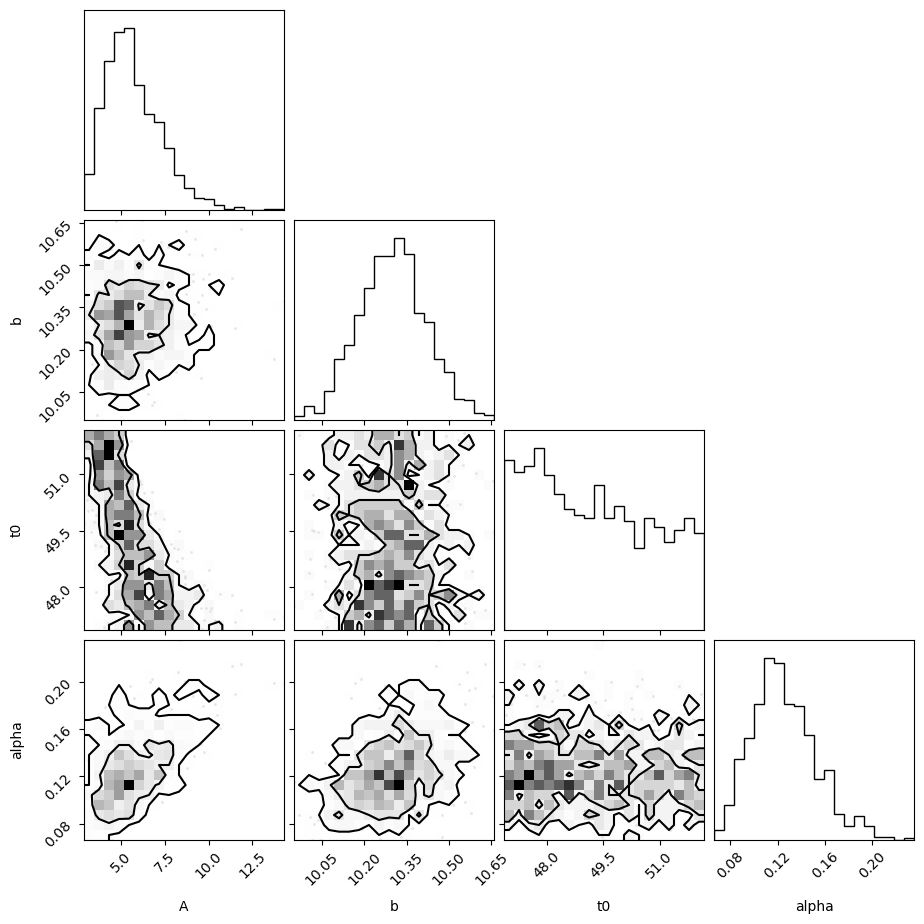

In [18]:
import corner

fig = corner.corner(emcee_trace, labels=labels, levels=[0.68,0.95]);

#you can see the negative correlation on A and to, you can chose a solution where A is larger and t es smaller and viceversa and both of then may explian the fit
#t0 i well constrain, why? who knows

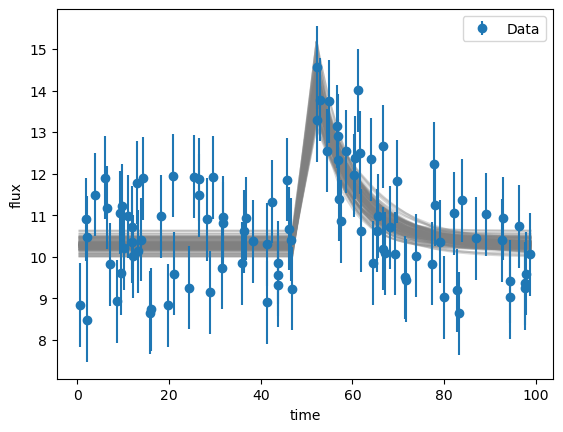

In [23]:
sample_indices = np.random.randint(0, len(emcee_trace), size=100)
sampled_params = emcee_trace[sample_indices]

t = data[:, 0]

for params in sampled_params:
    flux_model = burst(params, t)
    plt.plot(t, flux_model, alpha=0.3, color='gray')  

plt.errorbar(data[:, 0], data[:, 1], yerr=data[:, 2], fmt='o', label='Data')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend();